In [1]:
import numpy as np
from sedona.spark import SedonaContext
import itertools
import os

In [2]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext
sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/08 09:29:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/08 09:29:15 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/11/08 09:29:15 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/11/08 09:29:15 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/11/08 09:29:15 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/11/08 09:29:15 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/11/08 09:29:15 WARN SimpleFunctionRegistry: The function st_envelop

In [3]:
def plot_sedona_raster(df, band_number):
    import numpy as np
    import matplotlib.pyplot as plt

    array = df.select("rast").collect()[0][0].as_numpy_masked()[band_number]
    
    plt.figure(figsize=(5, 5))
    plt.imshow(array, cmap='Greens', interpolation='none')
    
    # Add the values on top of the cells
    for i in range(array.shape[0]):
        for j in range(array.shape[1]):
            plt.text(j, i, str(round(array[i, j], 1)), ha='center', va='center', color='black')
    
    plt.title('Green-scale Visualization with Values')
    plt.show()

def show_as_df(df, band_number):
    array = df.select("rast").collect()[0][0].as_numpy_masked()[band_number]
    print(np.round(array, 1))

# Map Algebra

In [4]:
input_raster_band_0 = [
    [1, 1, 16, 2, 6],
    [2, 3, 12, 16, 17],
    [8, 17, 5, 20, 7],
    [14, 8, 15, 4, 11],
    [10, 13, 19, 6, 9]
]

input_raster_band_1 = [
    [3, 14, 20, 1, 0],
    [7, 16, 9, 5, 2],
    [11, 4, 18, 13, 8],
    [6, 19, 15, 17, 10],
    [12, 3, 7, 0, 6],
]

input_raster_band_2 = [
    [12, 0, 17, 4, 15],
    [9, 3, 18, 6, 20],
    [5, 10, 14, 1, 13],
    [2, 11, 7, 19, 8],
    [16, 3, 0, 6, 12]
]

raster = [
    input_raster_band_0,
    input_raster_band_1,
    input_raster_band_2
]

In [5]:
flattened = list(itertools.chain.from_iterable(
    itertools.chain.from_iterable(raster)
))
array_input = ", ".join([str(number) for number in flattened ])

In [6]:
sedona.sql(
    f"""
    WITH empty_raster AS (
        SELECT RS_MakeEmptyRaster(3, 5, 5, 0.0, 5.0, 1.0, -1.0, 0.0, 0.0, 4326) AS rast
    )
    SELECT 
        RS_MakeRaster(rast, 'D', ARRAY({array_input})) AS rast
    FROM empty_raster
    """
).createOrReplaceTempView("ma")

In [19]:
sedona.sql("SELECT * FROM ma").show()

+--------------------+
|                rast|
+--------------------+
|GridCoverage2D["g...|
+--------------------+



## Access one band

In [8]:
access_first_element = sedona.sql(
    """
    SELECT
        RS_MapAlgebra(rast, NULL, 'out = rast[0];') AS rast
    FROM ma
    """
)

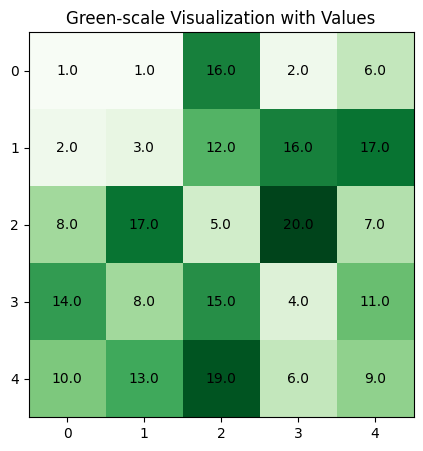

In [9]:
plot_sedona_raster(access_first_element, 0)

In [10]:
show_as_df(access_first_element, 0)

[[ 1.  1. 16.  2.  6.]
 [ 2.  3. 12. 16. 17.]
 [ 8. 17.  5. 20.  7.]
 [14.  8. 15.  4. 11.]
 [10. 13. 19.  6.  9.]]


## Mean from all bands

In [11]:
mean_of_bands = sedona.sql(
    """
    SELECT
        RS_MapAlgebra(
            rast,
            NULL,
            'out = (rast[0] + rast[1] + rast[2])/3;'
        ) AS rast
    FROM ma
    """
)

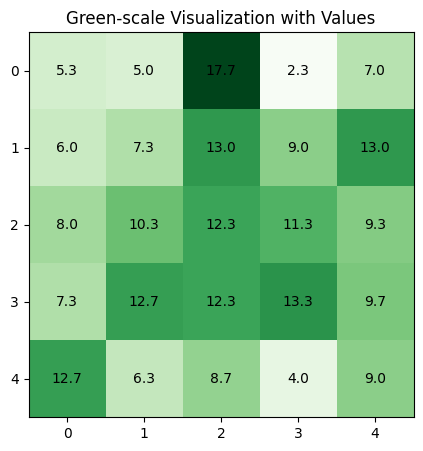

In [12]:
plot_sedona_raster(mean_of_bands, 0)

In [13]:
show_as_df(mean_of_bands, 0)

[[ 5.3  5.  17.7  2.3  7. ]
 [ 6.   7.3 13.   9.  13. ]
 [ 8.  10.3 12.3 11.3  9.3]
 [ 7.3 12.7 12.3 13.3  9.7]
 [12.7  6.3  8.7  4.   9. ]]


## Conditional expression

In [14]:
script = """
    mean_value = (rast[0] + rast[1] + rast[2])/3;
    
    out = (mean_value > 15 || mean_value < 8) ? -1 : mean_value;
"""

In [15]:
conditional = sedona.sql(
    f"""
    SELECT
        RS_MapAlgebra(rast, NULL, '{script}', -1) AS rast
    FROM ma
    """
)

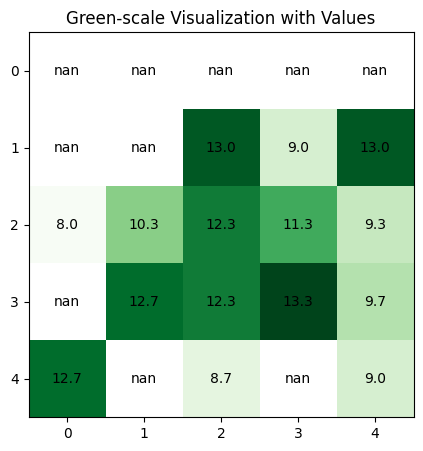

In [16]:
plot_sedona_raster(conditional, 0)

In [17]:
show_as_df(conditional, 0)

[[ nan  nan  nan  nan  nan]
 [ nan  nan 13.   9.  13. ]
 [ 8.  10.3 12.3 11.3  9.3]
 [ nan 12.7 12.3 13.3  9.7]
 [12.7  nan  8.7  nan  9. ]]


## Casting to boolean

In [34]:
script = """
    mean_value = (rast[0] + rast[1] + rast[2])/3;
    
    out = (mean_value > 15 || mean_value < 8) ? false : true;
"""

casting = sedona.sql(
    f"""
    SELECT
        RS_MapAlgebra(rast, 'B', '{script}') AS rast
    FROM ma
    """
)

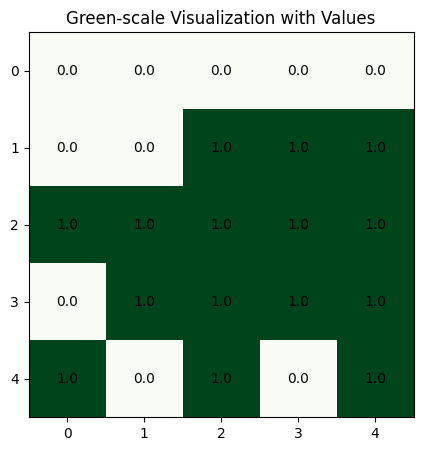

In [35]:
plot_sedona_raster(casting, 0)

In [36]:
show_as_df(casting, 0)

[[0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [1. 0. 1. 0. 1.]]


In [37]:
# cast to polygon
polygon = sedona.sql(
    f"""
    WITH pixelized AS (
        SELECT 
            RS_PixelAsPolygons(
                RS_MapAlgebra(rast, 'B', '{script}'),
                1
            ) AS pixels
        FROM ma
    )
    SELECT
        ST_Union_Aggr(pixel.geom) AS geom
    FROM pixelized
    LATERAL VIEW explode(pixels) AS pixel
    WHERE pixel.value = 1.0
    """
)

In [38]:
sedona.sql(
f"""
    SELECT 
        RS_PixelAsPolygons(
            RS_MapAlgebra(rast, 'B', '{script}'),
            1
        ) AS pixels
    FROM ma
"""
).printSchema()

root
 |-- pixels: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- geom: geometry (nullable = true)
 |    |    |-- value: double (nullable = true)
 |    |    |-- x: integer (nullable = true)
 |    |    |-- y: integer (nullable = true)



In [39]:
sedona.sql(
f"""
    WITH pixelized AS (
        SELECT 
            RS_PixelAsPolygons(
                RS_MapAlgebra(rast, 'B', '{script}', 0),
                1
            ) AS pixels
        FROM ma
    )
    SELECT
        pixel.*
    FROM pixelized
    LATERAL VIEW explode(pixels) AS pixel
"""
).show(5, False)

+-----------------------------------+-----+---+---+
|geom                               |value|x  |y  |
+-----------------------------------+-----+---+---+
|POLYGON ((0 5, 1 5, 1 4, 0 4, 0 5))|0.0  |1  |1  |
|POLYGON ((1 5, 2 5, 2 4, 1 4, 1 5))|0.0  |2  |1  |
|POLYGON ((2 5, 3 5, 3 4, 2 4, 2 5))|0.0  |3  |1  |
|POLYGON ((3 5, 4 5, 4 4, 3 4, 3 5))|0.0  |4  |1  |
|POLYGON ((4 5, 5 5, 5 4, 4 4, 4 5))|0.0  |5  |1  |
+-----------------------------------+-----+---+---+
only showing top 5 rows



In [40]:
polygon.show(1, False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------+
|geom                                                                                                                                                   |
+-------------------------------------------------------------------------------------------------------------------------------------------------------+
|MULTIPOLYGON (((0 1, 1 1, 1 0, 0 0, 0 1)), ((2 1, 1 1, 1 2, 0 2, 0 3, 1 3, 2 3, 2 4, 3 4, 4 4, 5 4, 5 3, 5 2, 5 1, 5 0, 4 0, 4 1, 3 1, 3 0, 2 0, 2 1)))|
+-------------------------------------------------------------------------------------------------------------------------------------------------------+



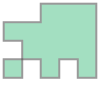

In [41]:
polygon.collect()[0][0]

## Applying mask 3x3 pixels

In [42]:
script = """
out = rast[0];
x = x();
y = y();
isWithinYRange = (y > 0 && y < height()-1);
isWithinXRange = (x > 0 && x < width()-1);


if (isWithinXRange && isWithinYRange) {
    delta = [-1, 0, 1];
    n = 0;
    foreach (dy in delta) {
        foreach (dx in delta) {
            n += rast[0][dx, dy];
        }
    }
    out = n/9;
}
"""

In [43]:
neighbor_avg = sedona.sql(
    f"""
    SELECT
        RS_MapAlgebra(rast, 'D', '{script}') AS rast
    FROM ma
    """
)

In [44]:
show_as_df(neighbor_avg, 0)

[[ 1.   1.  16.   2.   6. ]
 [ 2.   7.2 10.2 11.2 17. ]
 [ 8.   9.3 11.1 11.9  7. ]
 [14.  12.1 11.9 10.7 11. ]
 [10.  13.  19.   6.   9. ]]


In [45]:
## Use case

In [46]:
from pyspark.sql.functions import input_file_name

swir_channel = (
    sedona
        .read
        .format("binaryFile")
        .load(f"s3a://{bucket_name}/source_data/swir_b11_tiles")
        .withColumn("file_path", input_file_name())
        .selectExpr("RS_FromGeoTiff(content) AS rast", "file_path")
        .createOrReplaceTempView("swir_raw")
)

nir_channel = (
    sedona
        .read
        .format("binaryFile")
        .load(f"s3a://{bucket_name}/source_data/nir_b08_tiles")
        .withColumn("file_path", input_file_name())
        .selectExpr("RS_FromGeoTiff(content) AS rast", "file_path")
        .createOrReplaceTempView("nir_raw")
)


In [31]:
sedona.sql(
    """
    SELECT 
        rast,
        element_at(split(file_path, "/"), -1) AS file_name
    FROM nir_raw
    """
).createOrReplaceTempView("nir")

sedona.sql(
    """
    SELECT 
        rast,
        element_at(split(file_path, "/"), -1) AS file_name
    FROM swir_raw
    """
).createOrReplaceTempView("swir")

In [32]:
sedona.sql(
    """
    SELECT
        RS_MapAlgebra(
            n.rast,
            s.rast,
            'D',
            'out = (rast0-rast1)/(rast0+rast1);',
            -9999
        ) AS rast
    FROM swir AS s
    JOIN nir AS n ON s.file_name = n.file_name
    """
).show()

+--------------------+
|                rast|
+--------------------+
|GridCoverage2D["g...|
|GridCoverage2D["g...|
|GridCoverage2D["g...|
|GridCoverage2D["g...|
|GridCoverage2D["g...|
|GridCoverage2D["g...|
|GridCoverage2D["g...|
|GridCoverage2D["g...|
|GridCoverage2D["g...|
+--------------------+

